In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (7,245 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 121749 files and dire

In [ ]:
import matplotlib

# 맑은 고딕 적용
matplotlib.rc("font", family = "Nanum Gothic")
# 음수 표시
matplotlib.rc('axes', unicode_minus=False)

In [ ]:
# 실행결과 경고메시지 출력 제외
import warnings

warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd
import numpy as np

# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib

import seaborn as sns

In [ ]:
plt.rc('font', family='NanumBarunGothic')

In [ ]:
df_raw = pd.read_csv('/content/drive/MyDrive/최강<포빅아A4>/인도 중고차 /박주형/car_final.csv')
df_raw.head()

,Price,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Brand,Vehicle_Age,Brand_Group,city_location
0,2682.68,72000,2,1,1,26.60,998.0,58.16,5.0,18,14,1,2
1,19162.00,41000,0,1,1,19.67,1582.0,126.20,5.0,11,9,1,2
2,6898.32,46000,1,1,1,18.20,1199.0,88.70,5.0,10,13,1,3
3,9197.76,87000,0,1,1,20.77,1248.0,88.76,7.0,18,12,1,3
4,27194.71,40670,0,2,2,15.20,1968.0,140.80,5.0,1,11,2,3


In [ ]:
df_raw.isnull().sum()

Name                 0
Location             0
Price                0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
dtype: int64

경차 : 1000cc 미만  
소형차 : 1600cc 미만  
중형차: 2000cc미만  

대형차 : 2000cc이상

In [ ]:
# 'Engine' 열을 기준으로 'engine_group' 파생 변수 만들기
df_raw['engine_group'] = pd.cut(df_raw['Engine'], bins=[0, 1000, 1600, 2000, float('inf')], labels=[0,1,2,3], right=False)
df_raw

,Price,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Brand,Vehicle_Age,Brand_Group,city_location,engine_group
0,2682.68,72000,2,1,1,26.60,998.0,58.16,5.0,18,14,1,2,0
1,19162.00,41000,0,1,1,19.67,1582.0,126.20,5.0,11,9,1,2,1
2,6898.32,46000,1,1,1,18.20,1199.0,88.70,5.0,10,13,1,3,1
3,9197.76,87000,0,1,1,20.77,1248.0,88.76,7.0,18,12,1,3,1
4,27194.71,40670,0,2,2,15.20,1968.0,140.80,5.0,1,11,2,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5989,10822.70,41413,0,1,1,27.28,1047.0,69.00,5.0,28,8,1,2,1
5990,13474.72,39015,1,1,1,17.00,1497.0,121.36,5.0,8,7,1,3,1
5991,27838.55,6000,1,1,1,16.00,1368.0,160.00,5.0,14,6,1,2,1
5992,16203.39,21380,0,1,1,24.30,1248.0,88.50,5.0,18,7,1,3,1


In [ ]:
df_raw['engine_group'].describe()

count     5994
unique       4
top          1
freq      3464
Name: engine_group, dtype: int64

In [ ]:
# 가격 데이터에 로그 변환 적용 (0이거나 음수인 값이 없다고 가정)
df_raw['log_price'] = np.log1p(df_raw['Price'])  # log1p는 1을 더한 후 로그 변환을 수행

# price 극단치 데이터 처리

# 'log_price' 열에 대한 Q1과 Q3 계산
Q1 = df_raw['log_price'].quantile(0.25)
Q3 = df_raw['log_price'].quantile(0.75)
IQR = Q3 - Q1

# IQR을 사용하여 이상치가 아닌 데이터의 범위 정의
lower_bound = Q1 - 1.5 * IQR

df_raw= df_raw[df_raw['log_price'] >= lower_bound ]

In [ ]:
df_raw

,Price,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Brand,Vehicle_Age,Brand_Group,city_location,engine_group,log_price
0,2682.68,72000,2,1,1,26.60,998.0,58.16,5.0,18,14,1,2,0,7.894944
1,19162.00,41000,0,1,1,19.67,1582.0,126.20,5.0,11,9,1,2,1,9.860737
2,6898.32,46000,1,1,1,18.20,1199.0,88.70,5.0,10,13,1,3,1,8.839178
3,9197.76,87000,0,1,1,20.77,1248.0,88.76,7.0,18,12,1,3,1,9.126824
4,27194.71,40670,0,2,2,15.20,1968.0,140.80,5.0,1,11,2,3,2,10.210815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5988,8477.27,36000,1,1,1,19.83,1198.0,67.00,5.0,5,8,3,3,1,9.045262
5989,10822.70,41413,0,1,1,27.28,1047.0,69.00,5.0,28,8,1,2,1,9.289493
5990,13474.72,39015,1,1,1,17.00,1497.0,121.36,5.0,8,7,1,3,1,9.508645
5991,27838.55,6000,1,1,1,16.00,1368.0,160.00,5.0,14,6,1,2,1,10.234213


(array([2.888e+03, 1.890e+03, 9.100e+02, 2.000e+02, 5.100e+01, 1.900e+01,
        6.000e+00, 5.000e+00, 4.000e+00, 2.000e+00]),
 array([ 34.2 ,  92.38, 150.56, 208.74, 266.92, 325.1 , 383.28, 441.46,
        499.64, 557.82, 616.  ]),
 <BarContainer object of 10 artists>)

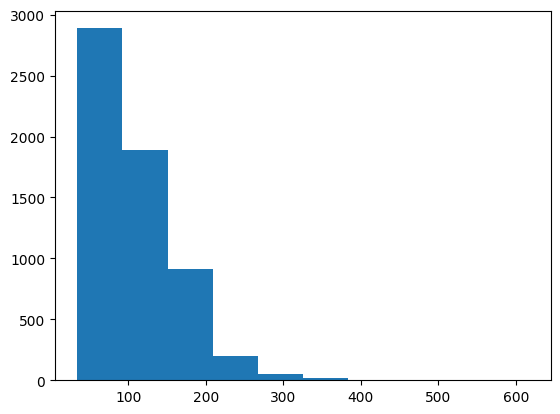

In [ ]:
plt.hist(df_raw['Power'])

In [ ]:
# 로그 변환 적용
df_raw['Power_log'] = np.log(df_raw['Power'])

In [ ]:
df_raw = df_raw.drop(['Price','Power'],axis = 1)

In [ ]:
df_raw

,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Seats,Brand,Vehicle_Age,Brand_Group,city_location,engine_group,log_price,Power_log
0,72000,2,1,1,26.60,998.0,5.0,18,14,1,2,0,7.894944,4.063198
1,41000,0,1,1,19.67,1582.0,5.0,11,9,1,2,1,9.860737,4.837868
2,46000,1,1,1,18.20,1199.0,5.0,10,13,1,3,1,8.839178,4.485260
3,87000,0,1,1,20.77,1248.0,7.0,18,12,1,3,1,9.126824,4.485936
4,40670,0,2,2,15.20,1968.0,5.0,1,11,2,3,2,10.210815,4.947340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5988,36000,1,1,1,19.83,1198.0,5.0,5,8,3,3,1,9.045262,4.204693
5989,41413,0,1,1,27.28,1047.0,5.0,28,8,1,2,1,9.289493,4.234107
5990,39015,1,1,1,17.00,1497.0,5.0,8,7,1,3,1,9.508645,4.798761
5991,6000,1,1,1,16.00,1368.0,5.0,14,6,1,2,1,10.234213,5.075174


In [ ]:
df_raw = df_raw.drop('Brand_Group',axis = 1)

In [ ]:
df_raw

,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Seats,Brand,Vehicle_Age,city_location,engine_group,log_price,Power_log
0,72000,2,1,1,26.60,998.0,5.0,18,14,2,0,7.894944,4.063198
1,41000,0,1,1,19.67,1582.0,5.0,11,9,2,1,9.860737,4.837868
2,46000,1,1,1,18.20,1199.0,5.0,10,13,3,1,8.839178,4.485260
3,87000,0,1,1,20.77,1248.0,7.0,18,12,3,1,9.126824,4.485936
4,40670,0,2,2,15.20,1968.0,5.0,1,11,3,2,10.210815,4.947340
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5988,36000,1,1,1,19.83,1198.0,5.0,5,8,3,1,9.045262,4.204693
5989,41413,0,1,1,27.28,1047.0,5.0,28,8,2,1,9.289493,4.234107
5990,39015,1,1,1,17.00,1497.0,5.0,8,7,3,1,9.508645,4.798761
5991,6000,1,1,1,16.00,1368.0,5.0,14,6,2,1,10.234213,5.075174


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5975 entries, 0 to 5992
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Kilometers_Driven  5975 non-null   int64   
 1   Fuel_Type          5975 non-null   int64   
 2   Transmission       5975 non-null   int64   
 3   Owner_Type         5975 non-null   int64   
 4   Mileage            5975 non-null   float64 
 5   Engine             5975 non-null   float64 
 6   Seats              5975 non-null   float64 
 7   Brand              5975 non-null   int64   
 8   Vehicle_Age        5975 non-null   int64   
 9   city_location      5975 non-null   int64   
 10  engine_group       5975 non-null   category
 11  log_price          5975 non-null   float64 
 12  Power_log          5975 non-null   float64 
dtypes: category(1), float64(5), int64(7)
memory usage: 612.9 KB


In [ ]:
from sklearn.preprocessing import LabelEncoder

# LabelEncoder 객체 생성
label_encoder = LabelEncoder()

# 카테고리 변수를 숫자로 변환
df_raw['engine_group'] = label_encoder.fit_transform(df_raw['engine_group'])
df_raw

,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Seats,Brand,Vehicle_Age,city_location,engine_group,log_price,Power_log
0,72000,2,1,1,26.60,998.0,5.0,18,14,2,0,7.894944,4.063198
1,41000,0,1,1,19.67,1582.0,5.0,11,9,2,1,9.860737,4.837868
2,46000,1,1,1,18.20,1199.0,5.0,10,13,3,1,8.839178,4.485260
3,87000,0,1,1,20.77,1248.0,7.0,18,12,3,1,9.126824,4.485936
4,40670,0,2,2,15.20,1968.0,5.0,1,11,3,2,10.210815,4.947340
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5988,36000,1,1,1,19.83,1198.0,5.0,5,8,3,1,9.045262,4.204693
5989,41413,0,1,1,27.28,1047.0,5.0,28,8,2,1,9.289493,4.234107
5990,39015,1,1,1,17.00,1497.0,5.0,8,7,3,1,9.508645,4.798761
5991,6000,1,1,1,16.00,1368.0,5.0,14,6,2,1,10.234213,5.075174


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5975 entries, 0 to 5992
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Kilometers_Driven  5975 non-null   int64  
 1   Fuel_Type          5975 non-null   int64  
 2   Transmission       5975 non-null   int64  
 3   Owner_Type         5975 non-null   int64  
 4   Mileage            5975 non-null   float64
 5   Engine             5975 non-null   float64
 6   Seats              5975 non-null   float64
 7   Brand              5975 non-null   int64  
 8   Vehicle_Age        5975 non-null   int64  
 9   city_location      5975 non-null   int64  
 10  engine_group       5975 non-null   int64  
 11  log_price          5975 non-null   float64
 12  Power_log          5975 non-null   float64
dtypes: float64(5), int64(8)
memory usage: 653.5 KB


In [ ]:
# csv파일 저장
df_raw.to_csv('real_final.csv', index=False)